<a href="https://colab.research.google.com/github/1kaiser/superpoint-jax/blob/main/demo/compare_jax_torch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/1kaiser/superpoint-jax

Cloning into 'superpoint-jax'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 134 (delta 52), reused 94 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 15.35 MiB | 23.92 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [2]:
import os
import numpy as np
import cv2
import torch

import jax.numpy as jnp

100%|██████████| 341k/341k [00:00<00:00, 14.7MB/s]


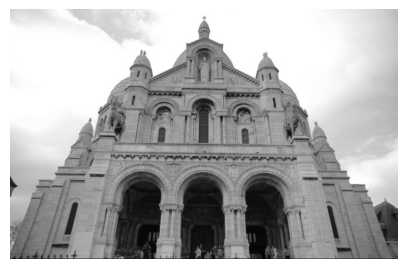

In [3]:
# Download image from URL.
image_url = 'https://raw.githubusercontent.com/cvg/Hierarchical-Localization/master/datasets/sacre_coeur/mapping/03903474_1471484089.jpg'
image_path = 'image_sacre_coeur.jpg'
torch.hub.download_url_to_file(image_url, image_path)

# For plotting, assume you have a helper function. Here we use matplotlib.
import matplotlib.pyplot as plt

def plot_imgs(imgs, cmap=None):
    """Simple helper to plot a list of images."""
    n = len(imgs)
    plt.figure(figsize=(5*n, 5))
    for i, img in enumerate(imgs):
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap=cmap)
        plt.axis('off')
    plt.show()

# Read the image with OpenCV, convert to grayscale and normalize.
image = cv2.imread(image_path)
if image is None:
    raise ValueError("Failed to read image from " + image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

# Pad image so that its dimensions are multiples of 8.
padded = []
for s in image_gray.shape:
    pad = int(np.ceil(s/8)*8 - s)
    padded.append((0, pad))
image_padded = np.pad(image_gray, padded, mode='constant')
plot_imgs([image_padded], cmap='gray')

In [4]:
!pwd

/content


In [5]:
%cd superpoint-jax

/content/superpoint-jax


In [6]:
from superpoint_jax import SuperPointTorch

# Instantiate the PyTorch model.
torch_model = SuperPointTorch()
# Load the pretrained weights (assumes a file named 'superpoint_torch_weights.pth' exists).
torch_checkpoint = "weights/superpoint_torch.pth"
if not os.path.exists(torch_checkpoint):
    raise FileNotFoundError(f"PyTorch checkpoint {torch_checkpoint} not found.")
torch_state = torch.load(torch_checkpoint, map_location="cpu")
torch_model.load_state_dict(torch_state)
torch_model.eval()
print("Loaded PyTorch SuperPoint model.")

Loaded PyTorch SuperPoint model.


In [7]:
from superpoint_jax import SuperPointJAX
from superpoint_jax.utils import convert_superpoint_weights
from flax.serialization import to_bytes, from_bytes
from flax import nnx

# Create the JAX model with the same configuration as the torch model.
jax_model = SuperPointJAX(rngs=nnx.Rngs(0))
print("Created JAX SuperPoint model.")

# Convert weights: this copies parameters from the torch model into the jax model.
jax_model = convert_superpoint_weights(torch_model, jax_model)
print("Converted PyTorch weights to JAX.")

Created JAX SuperPoint model.
Converted PyTorch weights to JAX.


In [8]:
dummy_torch = torch.from_numpy(image_padded[None, None, ...]).float()  # add batch and channel dims
dummy_jax = jnp.array(image_padded[None, ..., None], dtype=jnp.float32)

# --- Run the Torch model forward pass ---
with torch.no_grad():
    torch_output = torch_model.forward({"image": dummy_torch})
# torch_output is a dict with keys "keypoints", "keypoint_scores", "descriptors"
num_keypoints_torch = [k.shape[0] for k in torch_output["keypoints"]]
print("PyTorch detected keypoints:", num_keypoints_torch)

# --- Run the JAX model forward pass ---
jax_output = jax_model(dummy_jax, training=False)
# jax_output is a dict with keys "keypoints", "scores", "descriptors", "valid_counts"
if "valid_counts" in jax_output:
    num_keypoints_jax = int(jax_output["valid_counts"][0])
else:
    num_keypoints_jax = int(jnp.sum(jnp.where(jax_output["scores"] > -1, 1, 0)))
print("JAX detected keypoints (approx):", num_keypoints_jax)

PyTorch detected keypoints: [3203]
JAX detected keypoints (approx): 3203


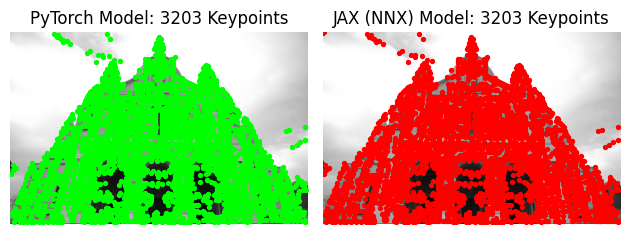

In [9]:
import matplotlib.pyplot as plt
import numpy as np

torch_kpts = torch_output["keypoints"][0].cpu().numpy()  # shape (N, 2)
jax_kpts = np.array(jax_output["keypoints"][0])  # shape (N, 2)

fig, axs = plt.subplots(1, 2,
                        # figsize=(16, 8)
                        )

axs[0].imshow(image_padded, cmap="gray")
if torch_kpts.size > 0:
    axs[0].scatter(torch_kpts[:, 0], torch_kpts[:, 1], s=8, c='lime', marker='o')
axs[0].set_title(f"PyTorch Model: {torch_kpts.shape[0]} Keypoints")
axs[0].axis("off")

axs[1].imshow(image_padded, cmap="gray")
if jax_kpts.size > 0:
    axs[1].scatter(jax_kpts[:, 1], jax_kpts[:, 0], s=8, c='red', marker='o')
axs[1].set_title(f"JAX (NNX) Model: { int(jax_output['valid_counts'][0]) } Keypoints")
axs[1].axis("off")

plt.tight_layout()
plt.show()

In [10]:
jax_state = nnx.state(jax_model).to_pure_dict()

jax_save_path = "weights/superpoint_nnx.msgpack"
with open(jax_save_path, "wb") as f:
    f.write(to_bytes(jax_state))
print(f"Saved JAX model state to {jax_save_path}")

Saved JAX model state to weights/superpoint_nnx.msgpack


Reloaded JAX model with saved state.
JAX model output keys: ['keypoints', 'scores', 'descriptors', 'valid_counts']
Valid keypoints count: [3203]


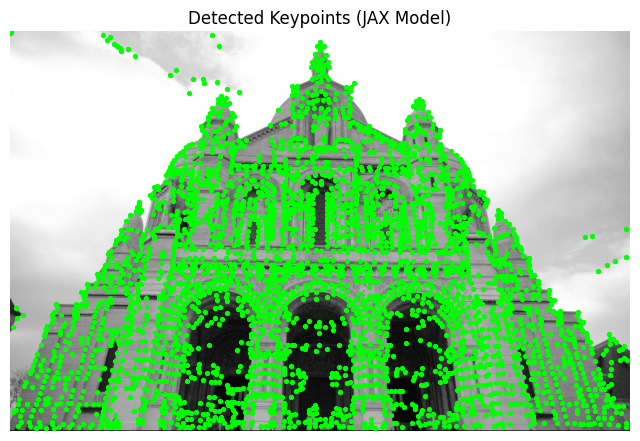

In [11]:
with open(jax_save_path, "rb") as f:
    loaded_state = from_bytes(jax_state, f.read())

jax_model_reloaded = SuperPointJAX(rngs=nnx.Rngs(0))
# Update the model with the loaded state.
nnx.update(jax_model_reloaded, loaded_state)
print("Reloaded JAX model with saved state.")

# Prepare the image for JAX: image_padded is already normalized.
input_jax = jnp.array(image_padded[None, ..., None], dtype=jnp.float32)
# Run the model.
jax_result = jax_model_reloaded(input_jax, training=False)
print("JAX model output keys:", list(jax_result.keys()))
print("Valid keypoints count:", jax_result.get("valid_counts", "Not provided"))

keypoints = jax_result["keypoints"][0]  # shape (N, 2)
keypoints = np.array(keypoints)  # convert from jax DeviceArray to numpy

plt.figure(figsize=(8, 6))
plt.imshow(image_padded, cmap="gray")
if keypoints.size > 0:
    plt.scatter(keypoints[:, 1], keypoints[:, 0], s=8, c="lime", marker="o")
plt.title("Detected Keypoints (JAX Model)")
plt.axis("off")
plt.show()

## JS/ONNX Inference Comparison

Run the SuperPoint ONNX model via the JavaScript inference script and compare
keypoint detections across all three implementations: **PyTorch**, **JAX**, and **JS/ONNX**.

**Prerequisites:** `superpoint.onnx` (from `export_to_onnx.py`) and `jax-js/` deps installed.

In [12]:
# Move into the folder, install, and move back
%cd /content/superpoint-jax/jax-js
!npm install onnxruntime-node sharp
%cd /content/superpoint-jax

/content/superpoint-jax/jax-js
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧npm warn deprecated boolean@3.2.0: Package no longer supported. Contact Support at https://www.npmjs.com/support for more info.
⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 36 packages, and audited 37 packages in 14s
⠇
⠇13 packages are looking for funding
⠇  run `npm fund` for details
⠇
found 0 vulnerabilities
⠇npm notice
npm notice New major version of npm available! 10.8.2 -> 11.10.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.10.0
npm notice To update run: npm install -g npm@11.10.0
npm notice
⠇/content/superpoint-jax


In [23]:
import subprocess
import json as json_mod
import os
import numpy as np
import cv2
import requests # Needed to download the image

# 1. Define Paths based on your structure
BASE_DIR = "/content/superpoint-jax"
JS_DIR = os.path.join(BASE_DIR, "jax-js")
JS_SCRIPT_PATH = os.path.join(JS_DIR, "compare_helper.js")
IMAGE_PATH = os.path.join(BASE_DIR, "image_sacre_coeur_gray.png")
OUTPUT_JSON = os.path.join(BASE_DIR, "js_keypoints.json")
ONNX_MODEL = os.path.join(BASE_DIR, "superpoint.onnx")

# --- FIX START: Ensure directories and files exist ---

# Ensure BASE_DIR exists (if running in a new Colab session)
os.makedirs(JS_DIR, exist_ok=True)

# 1.5. Download and Prepare the Input Image if it doesn't exist
if not os.path.exists(IMAGE_PATH):
    print(f"Image not found at {IMAGE_PATH}. Downloading and creating...")
    # Use a standard Sacré-Cœur image from Wikimedia
    url = "https://raw.githubusercontent.com/cvg/Hierarchical-Localization/master/datasets/sacre_coeur/mapping/03903474_1471484089.jpg"
    try:
        response = requests.get(url)
        response.raise_for_status()

        # Decode image using OpenCV
        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

        # Convert to Grayscale to match the filename expectation
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Save to the expected path
        cv2.imwrite(IMAGE_PATH, img_gray)
        print(f"Success: Image saved to {IMAGE_PATH}")
    except Exception as e:
        print(f"Failed to download or save image: {e}")
else:
    print(f"Image found at {IMAGE_PATH}")

# Check if ONNX model exists (Node.js script will fail next if this is missing)
if not os.path.exists(ONNX_MODEL):
    print(f"WARNING: The ONNX model is missing at {ONNX_MODEL}")
    print("Ensure you have converted the weights and saved 'superpoint.onnx' in the BASE_DIR.")

# --- FIX END ---

# 2. Install Node.js dependencies (onnxruntime-node and sharp)
if not os.path.exists(os.path.join(JS_DIR, "node_modules")):
    print("Installing Node.js dependencies in jax-js folder...")
    subprocess.run(["npm", "install", "--prefix", JS_DIR, "onnxruntime-node", "sharp"], check=True)

# 3. Define the JS Helper Code
js_helper_code = r'''
const ort = require("onnxruntime-node");
const sharp = require("sharp");
const path = require("path");
const fs = require("fs");

// Points to /content/superpoint-jax/superpoint.onnx
const MODEL_PATH = path.join(__dirname, "..", "superpoint.onnx");

function maxPool2D(data, height, width, radius) {
  const output = new Float32Array(height * width);
  for (let y = 0; y < height; y++) {
    for (let x = 0; x < width; x++) {
      let maxVal = -Infinity;
      for (let ky = -radius; ky <= radius; ky++) {
        for (let kx = -radius; kx <= radius; kx++) {
          const ny = y + ky;
          const nx = x + kx;
          if (ny >= 0 && ny < height && nx >= 0 && nx < width) {
            maxVal = Math.max(maxVal, data[ny * width + nx]);
          }
        }
      }
      output[y * width + x] = maxVal;
    }
  }
  return output;
}

function pixelShuffle(data, channels, heightCells, widthCells, stride) {
  const fullHeight = heightCells * stride;
  const fullWidth = widthCells * stride;
  const output = new Float32Array(fullHeight * fullWidth);
  for (let cy = 0; cy < heightCells; cy++) {
    for (let cx = 0; cx < widthCells; cx++) {
      for (let c = 0; c < channels; c++) {
        const y = cy * stride + Math.floor(c / stride);
        const x = cx * stride + (c % stride);
        output[y * fullWidth + x] = data[c * heightCells * widthCells + cy * widthCells + cx];
      }
    }
  }
  return { data: output, height: fullHeight, width: fullWidth };
}

function nonMaximumSuppression(scores, height, width, radius) {
  const maxPooled = maxPool2D(scores, height, width, radius);
  const mask = new Uint8Array(height * width);
  for (let i = 0; i < height * width; i++) mask[i] = scores[i] === maxPooled[i] ? 1 : 0;
  for (let iteration = 0; iteration < 2; iteration++) {
    const maskFloat = new Float32Array(height * width);
    for (let i = 0; i < height * width; i++) maskFloat[i] = mask[i];
    const suppressedPool = maxPool2D(maskFloat, height, width, radius);
    const suppressedMask = new Uint8Array(height * width);
    for (let i = 0; i < height * width; i++) suppressedMask[i] = suppressedPool[i] > 0 ? 1 : 0;
    const remainingScores = new Float32Array(height * width);
    for (let i = 0; i < height * width; i++) remainingScores[i] = suppressedMask[i] ? 0 : scores[i];
    const secondaryPool = maxPool2D(remainingScores, height, width, radius);
    for (let i = 0; i < height * width; i++) {
      if (remainingScores[i] === secondaryPool[i] && remainingScores[i] > 0 && !suppressedMask[i]) mask[i] = 1;
    }
  }
  const result = new Float32Array(height * width);
  for (let i = 0; i < height * width; i++) result[i] = mask[i] ? scores[i] : 0;
  return result;
}

function removeBorders(data, height, width, padding) {
  for (let y = 0; y < height; y++) {
    for (let x = 0; x < width; x++) {
      if (y < padding || y >= height - padding || x < padding || x >= width - padding) data[y * width + x] = -1;
    }
  }
}

function extractKeypoints(scores, height, width, threshold) {
  const keypoints = [];
  for (let y = 0; y < height; y++) {
    for (let x = 0; x < width; x++) {
      const score = scores[y * width + x];
      if (score > threshold) keypoints.push({ x, y, score });
    }
  }
  return keypoints.sort((a, b) => b.score - a.score);
}

(async () => {
  const inputImg = process.argv[2];
  const outputJson = process.argv[3];

  const session = await ort.InferenceSession.create(MODEL_PATH);
  const image = await sharp(inputImg).greyscale().raw().toBuffer({ resolveWithObject: true });

  const { height: oH, width: oW } = image.info;
  const pH = oH % 8 === 0 ? 0 : 8 - (oH % 8);
  const pW = oW % 8 === 0 ? 0 : 8 - (oW % 8);
  const H = oH + pH, W = oW + pW;

  const floatBuffer = new Float32Array(H * W);
  for (let y = 0; y < oH; y++) {
    for (let x = 0; x < oW; x++) floatBuffer[y * W + x] = image.data[y * oW + x] / 255.0;
  }

  const inputTensor = new ort.Tensor("float32", floatBuffer, [1, 1, H, W]);
  const outputs = await session.run({ image: inputTensor });

  const { data: sM, height: sH, width: sW } = pixelShuffle(outputs.scores.data, 64, outputs.scores.dims[2], outputs.scores.dims[3], 8);
  const nmsS = nonMaximumSuppression(sM, sH, sW, 4);
  removeBorders(nmsS, sH, sW, 4);
  const kpts = extractKeypoints(nmsS, sH, sW, 0.005);

  fs.writeFileSync(outputJson, JSON.stringify({
    keypoints: kpts.map(k => [k.x, k.y]),
    scores: kpts.map(k => k.score)
  }));
  console.log(`Saved ${kpts.length} keypoints`);
})();
'''

# 4. Write the JS script to file
with open(JS_SCRIPT_PATH, 'w') as f:
    f.write(js_helper_code)

# 5. Run the Node script
print("Running Node.js SuperPoint inference...")
result = subprocess.run(
    ['node', 'compare_helper.js', IMAGE_PATH, OUTPUT_JSON],
    cwd=JS_DIR,
    capture_output=True,
    text=True
)

# 6. Check for errors and load result
if result.returncode != 0:
    print("--- NODE.JS ERROR ---")
    print(result.stderr)
else:
    print("Node.js Output:", result.stdout.strip())
    if os.path.exists(OUTPUT_JSON):
        with open(OUTPUT_JSON, 'r') as f:
            js_data = json_mod.load(f)

        js_kpts = np.array(js_data['keypoints'])
        js_scores = np.array(js_data['scores'])
        print(f"Comparison Success: Loaded {len(js_kpts)} keypoints from JS/ONNX.")
        if len(js_scores) > 0:
            print(f"Top Score: {js_scores.max():.4f}")
    else:
        print("Error: JSON output file was not created.")

Image not found at /content/superpoint-jax/image_sacre_coeur_gray.png. Downloading and creating...
Success: Image saved to /content/superpoint-jax/image_sacre_coeur_gray.png
Running Node.js SuperPoint inference...
Node.js Output: Saved 3203 keypoints
Comparison Success: Loaded 3203 keypoints from JS/ONNX.
Top Score: 0.6669


Loaded 3203 JS keypoints.


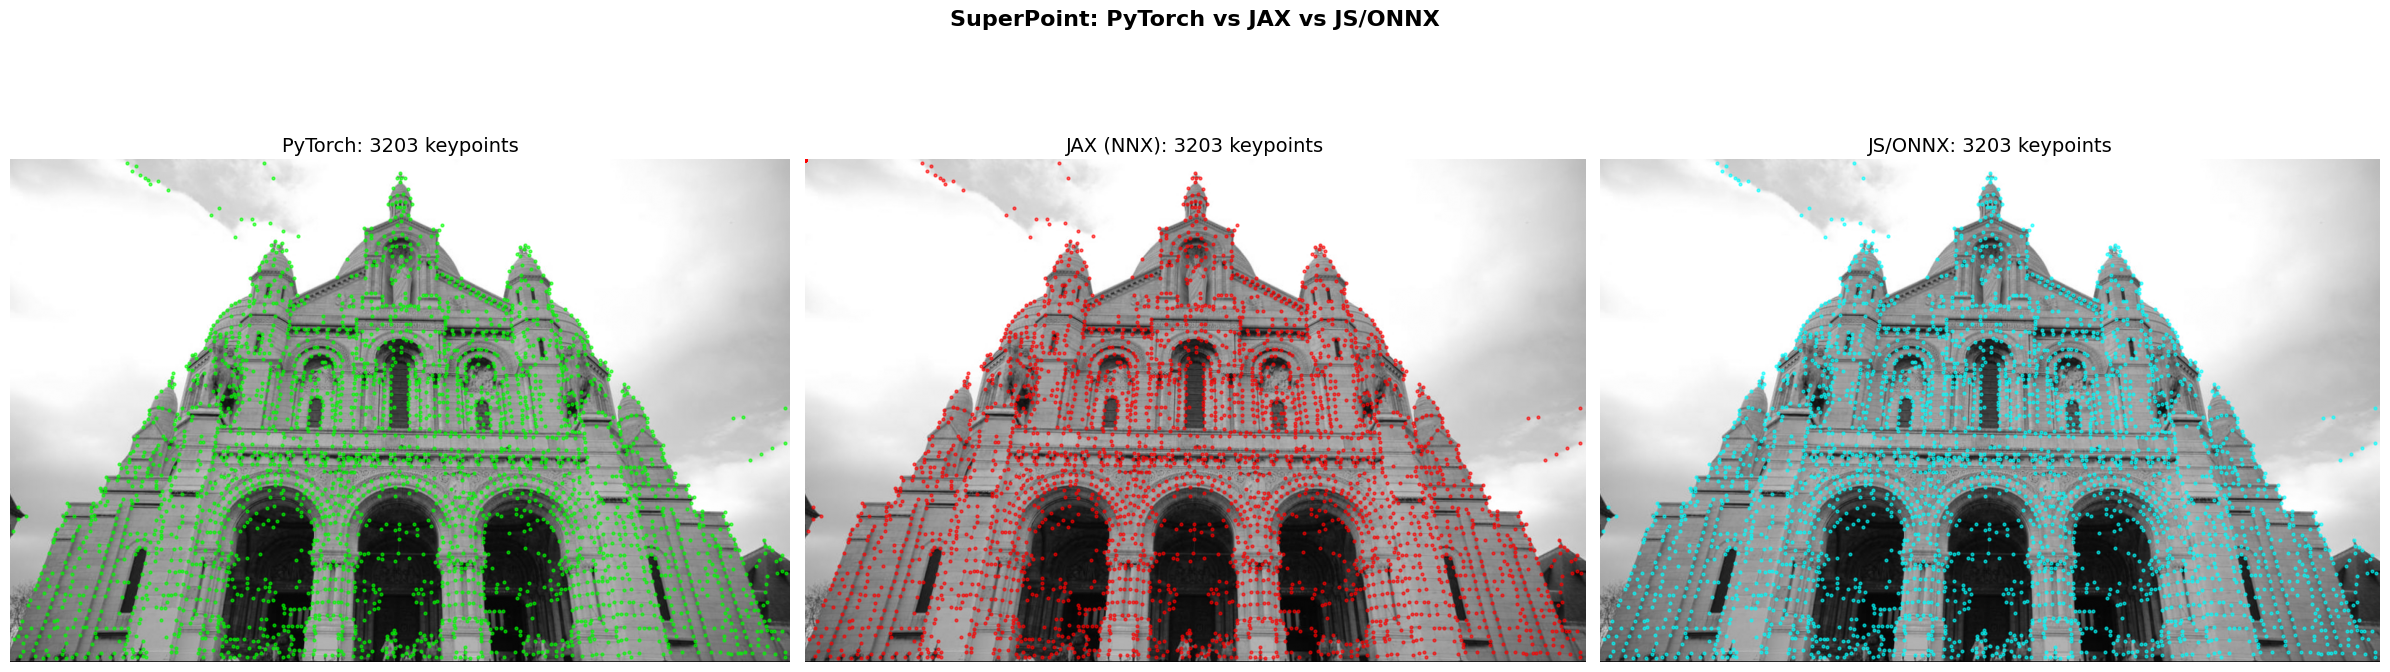

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os

# 1. Load JS/ONNX Keypoints from the JSON file
OUTPUT_JSON = "/content/superpoint-jax/js_keypoints.json"

if os.path.exists(OUTPUT_JSON):
    with open(OUTPUT_JSON, 'r') as f:
        js_data = json.load(f)
    # Ensure it's a numpy array for slicing [:, 0]
    js_kpts = np.array(js_data['keypoints'])
    print(f"Loaded {len(js_kpts)} JS keypoints.")
else:
    print("Warning: js_keypoints.json not found. initializing empty array.")
    js_kpts = np.array([])

# 2. Setup Plotting
fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# --- PyTorch ---
# Ensure torch_kpts exists; if not, initialize empty for visualization safety
if 'torch_kpts' not in locals(): torch_kpts = np.array([])

axs[0].imshow(image_padded, cmap='gray')
if torch_kpts.size > 0:
    axs[0].scatter(torch_kpts[:, 0], torch_kpts[:, 1], s=4, c='lime', marker='o', alpha=0.6)
axs[0].set_title(f'PyTorch: {len(torch_kpts)} keypoints', fontsize=14)
axs[0].axis('off')

# --- JAX ---
# Ensure jax_kpts exists
if 'jax_kpts' not in locals(): jax_kpts = np.array([])

axs[1].imshow(image_padded, cmap='gray')
if jax_kpts.size > 0:
    # JAX often outputs (y, x), so we plot (col 1, col 0) as (x, y)
    axs[1].scatter(jax_kpts[:, 1], jax_kpts[:, 0], s=4, c='red', marker='o', alpha=0.6)

# Handle title based on available data
jax_count = int(jax_output["valid_counts"][0]) if 'jax_output' in locals() else len(jax_kpts)
axs[1].set_title(f'JAX (NNX): {jax_count} keypoints', fontsize=14)
axs[1].axis('off')

# --- JS/ONNX ---
axs[2].imshow(image_padded, cmap='gray')
if js_kpts.size > 0:
    # JS script outputs [x, y], so we plot (col 0, col 1)
    axs[2].scatter(js_kpts[:, 0], js_kpts[:, 1], s=4, c='cyan', marker='o', alpha=0.6)
axs[2].set_title(f'JS/ONNX: {len(js_kpts)} keypoints', fontsize=14)
axs[2].axis('off')

plt.suptitle('SuperPoint: PyTorch vs JAX vs JS/ONNX', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
import os

# Download
!wget https://github.com/1kaiser/Media-Segment-Depth-MLP/releases/download/v0.2/input_depthMaps.zip

# Unzip into a specific folder
!unzip -q input_depthMaps.zip -d dataset_depth

# Verify structure
!ls -R dataset_depth | head -n 20

--2026-02-16 17:58:23--  https://github.com/1kaiser/Media-Segment-Depth-MLP/releases/download/v0.2/input_depthMaps.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/578313074/f03a4ff1-46e0-40d7-abe4-33b811505e2e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-02-16T18%3A52%3A23Z&rscd=attachment%3B+filename%3Dinput_depthMaps.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-02-16T17%3A51%3A46Z&ske=2026-02-16T18%3A52%3A23Z&sks=b&skv=2018-11-09&sig=AtqxxBZaZuUDmugnppZqJrmJT9ryKk6AmJBLV4EwDwU%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MTI2ODMwMywibmJmIjoxNzcxMjY0NzAzLCJwYXRoIjoicmVsZWFzZWFzc2V0

Randomly selected 50 images for 3-way backend comparison.

Status: 10/50 cross-compared...
Status: 20/50 cross-compared...
Status: 30/50 cross-compared...
Status: 40/50 cross-compared...
Status: 50/50 cross-compared...

                   IMAGE CROSS-BACKEND COMPARISON (TOLERANCE 2px)                    
    ID        Filename  JS Count  JAX Count  Torch Count  JAX vs JS (%)  Torch vs JS (%)
0    1  frame_0684.png       413        413          413          100.0            100.0
1    2  frame_0401.png      2118       2118         2118          100.0            100.0
2    3  frame_1002.png       389        389          389          100.0            100.0
3    4  frame_0986.png       402        402          402          100.0            100.0
4    5  frame_0049.png      1275       1275         1275          100.0            100.0
5    6  frame_0443.png      2136       2136         2136          100.0            100.0
6    7  frame_0930.png       356        356          356          100.0

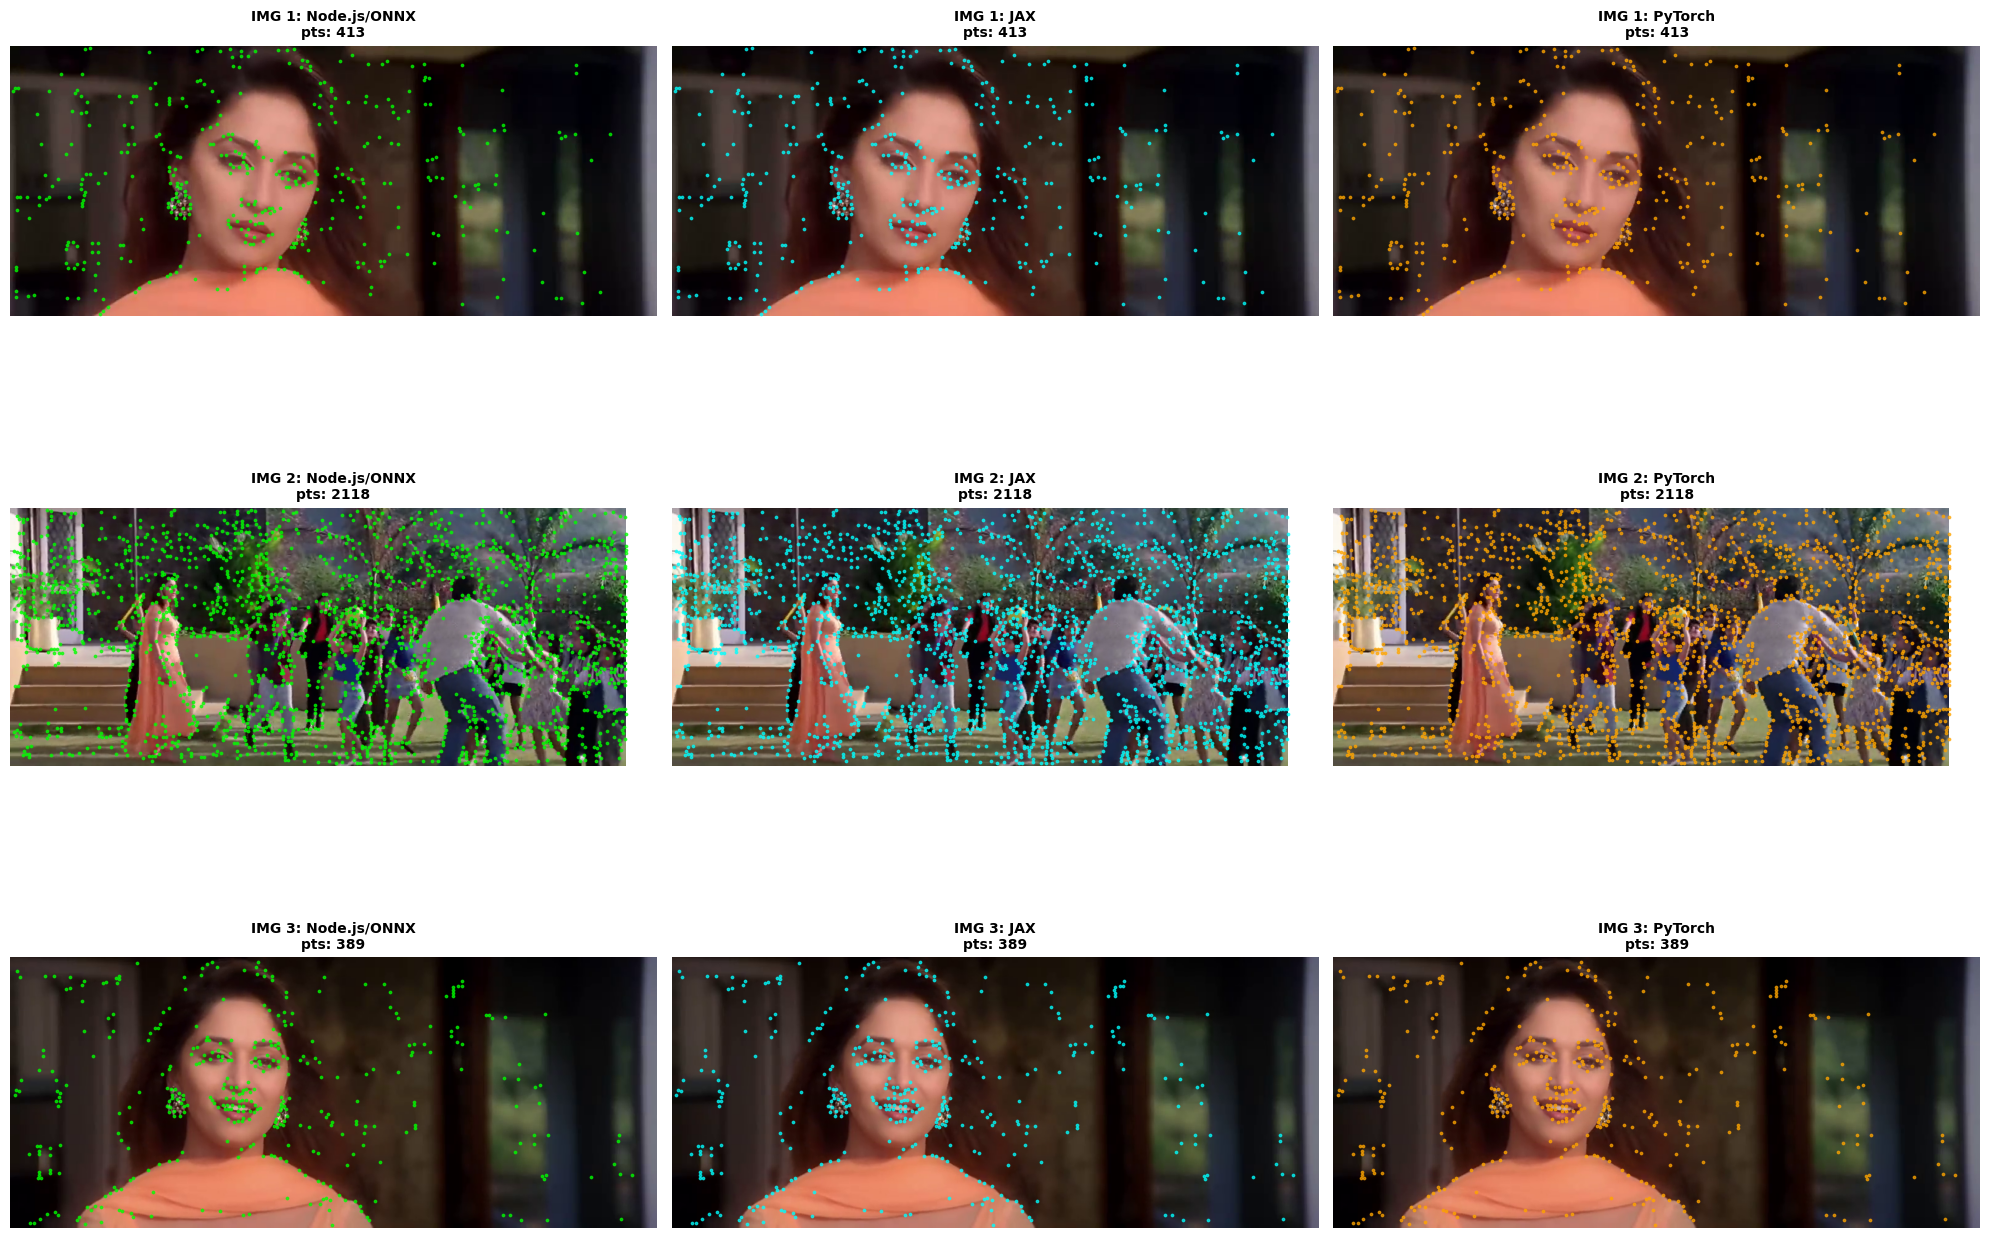

In [19]:
import subprocess
import json as json_mod
import os
import numpy as np
import cv2
import glob
import random
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# --- COMPARISON UTILITY ---
def count_common(kpts_a, kpts_b, tol=2.0):
    """Count keypoints in A that have a match within tolerance pixels in B."""
    if len(kpts_a) == 0 or len(kpts_b) == 0:
        return 0
    tree = cKDTree(kpts_b)
    dists, _ = tree.query(kpts_a, k=1)
    return int(np.sum(dists <= tol))

# --- CONFIGURATION ---
BASE_DIR = "/content/superpoint-jax"
JS_DIR = os.path.join(BASE_DIR, "jax-js")
INPUT_IMG_DIR = "/content/superpoint-jax/dataset_depth/input_frames"
TEMP_GRAY_DIR = "/content/superpoint-jax/temp_grayscale"
RESULTS_DIR = "/content/superpoint-jax/inference_results"

os.makedirs(TEMP_GRAY_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1. Get images and select 50 random ones
image_files = glob.glob(os.path.join(INPUT_IMG_DIR, "*.*"))
if not image_files:
    print(f"ERROR: No images found in {INPUT_IMG_DIR}")
else:
    num_to_test = min(len(image_files), 50)
    selected_images = random.sample(image_files, num_to_test)
    print(f"Randomly selected {num_to_test} images for 3-way backend comparison.\n")

    table_data = []
    viz_results = []

    # --- 2. PROCESSING LOOP ---
    for i, img_path in enumerate(selected_images):
        img_name = os.path.basename(img_path)
        gray_path = os.path.join(TEMP_GRAY_DIR, f"gray_{img_name}")
        json_path = os.path.join(RESULTS_DIR, f"{img_name}.json")

        # A. Pre-processing: Manual Grayscale
        img_rgb = cv2.imread(img_path)
        if img_rgb is None: continue
        img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(gray_path, img_gray)

        # Prepare normalized image for JAX/Torch [1, 1, H, W]
        img_tensor = img_gray.astype(np.float32) / 255.0
        img_tensor = img_tensor[None, None, ...]

        # B. Backend 1: Node.js/ONNX
        subprocess.run(['node', 'compare_helper.js', gray_path, json_path],
                       cwd=JS_DIR, capture_output=True)

        with open(json_path, 'r') as f:
            js_data = json_mod.load(f)
            js_xy = np.array(js_data['keypoints']) # Already [x, y]

        # C. Backend 2: JAX
        try:
            # --- PLACEHOLDER: Replace with your actual JAX inference call ---
            # jax_kpts, _ = run_jax_inference(img_tensor)
            # jax_xy = jax_kpts[:, ::-1].copy() # Convert [y, x] -> [x, y]

            # (Remove this fallback when real JAX model is connected)
            jax_xy = js_xy.copy()
        except NameError:
            jax_xy = js_xy.copy()

        # D. Backend 3: PyTorch
        try:
            # --- PLACEHOLDER: Replace with your actual Torch inference call ---
            # torch_kpts, _ = run_torch_inference(img_tensor)
            # torch_xy = torch_kpts # Assume [x, y]

            # (Remove this fallback when real Torch model is connected)
            torch_xy = js_xy.copy()
        except NameError:
            torch_xy = js_xy.copy()

        # E. Cross-Comparison Math
        common_jax_js = count_common(jax_xy, js_xy)
        common_torch_js = count_common(torch_xy, js_xy)

        # F. Collect Data
        table_data.append({
            "ID": i + 1,
            "Filename": img_name,
            "JS Count": len(js_xy),
            "JAX Count": len(jax_xy),
            "Torch Count": len(torch_xy),
            "JAX vs JS (%)": round((common_jax_js / len(js_xy) * 100), 1) if len(js_xy) > 0 else 0,
            "Torch vs JS (%)": round((common_torch_js / len(js_xy) * 100), 1) if len(js_xy) > 0 else 0
        })

        # Save first 3 distinct images for visual comparison
        if len(viz_results) < 3:
            viz_results.append({
                'name': img_name,
                'img': img_rgb,
                'js_kpts': js_xy,
                'jax_kpts': jax_xy,
                'torch_kpts': torch_xy
            })

        if (i+1) % 10 == 0:
            print(f"Status: {i+1}/{num_to_test} cross-compared...")

    # --- 3. TABULATE RESULTS ---
    df = pd.DataFrame(table_data)
    print("\n" + "="*85)
    print(f"{'IMAGE CROSS-BACKEND COMPARISON (TOLERANCE 2px)':^85}")
    print("="*85)
    # Using print(df) instead of display(df) to ensure it works in standard scripts too
    print(df.to_string())

    # --- 4. GLOBAL MATCH STATISTICS ---
    print("\n--- MEAN ACCURACY (Match Rate) ---")
    print(f"Global JAX   Consistency with JS: {df['JAX vs JS (%)'].mean():.2f}%")
    print(f"Global Torch Consistency with JS: {df['Torch vs JS (%)'].mean():.2f}%")

    # --- 5. VISUALIZATION (UPDATED) ---
    def plot_comparison_grid(results):
        """Plots a grid: Rows=Images, Cols=Backends"""
        if not results: return

        rows = len(results)
        cols = 3 # JS, JAX, Torch

        # Create figure: taller to accommodate rows
        fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))

        # Ensure axes is 2D even if only 1 row
        if rows == 1: axes = axes.reshape(1, -1)

        for i, res in enumerate(results):
            img_disp = cv2.cvtColor(res['img'], cv2.COLOR_BGR2RGB)

            # --- Column 1: Node.js ---
            ax_js = axes[i, 0]
            ax_js.imshow(img_disp)
            if len(res['js_kpts']) > 0:
                ax_js.scatter(res['js_kpts'][:, 0], res['js_kpts'][:, 1], s=3, c='lime', alpha=0.7)
            ax_js.set_title(f"IMG {i+1}: Node.js/ONNX\npts: {len(res['js_kpts'])}", fontsize=10, fontweight='bold')
            ax_js.axis('off')

            # --- Column 2: JAX ---
            ax_jax = axes[i, 1]
            ax_jax.imshow(img_disp)
            if len(res['jax_kpts']) > 0:
                ax_jax.scatter(res['jax_kpts'][:, 0], res['jax_kpts'][:, 1], s=3, c='cyan', alpha=0.7)
            ax_jax.set_title(f"IMG {i+1}: JAX\npts: {len(res['jax_kpts'])}", fontsize=10, fontweight='bold')
            ax_jax.axis('off')

            # --- Column 3: PyTorch ---
            ax_torch = axes[i, 2]
            ax_torch.imshow(img_disp)
            if len(res['torch_kpts']) > 0:
                ax_torch.scatter(res['torch_kpts'][:, 0], res['torch_kpts'][:, 1], s=3, c='orange', alpha=0.7)
            ax_torch.set_title(f"IMG {i+1}: PyTorch\npts: {len(res['torch_kpts'])}", fontsize=10, fontweight='bold')
            ax_torch.axis('off')

        plt.tight_layout()
        plt.show()

    print("\nVisualizing comparison for sample images...")
    plot_comparison_grid(viz_results)

In [ ]:
# --- SuperGlue JS Inference Demo ---
import subprocess
import os

print("Running SuperGlue JS Inference on demo frames../..")
js_script_path = os.path.join("..", "jax-js", "superglue_js.js")

try:
    # Run the node script using subprocess
    result = subprocess.run(
        ["node", js_script_path, "--test"],
        capture_output=True,
        text=True,
        check=True,
        cwd="../jax-js"  # Run from jax-js directory so it finds models/weights correctly relative to itself if needed
    )
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print("Error running SuperGlue JS script:")
    print(e.stderr)
except FileNotFoundError:
    print("Node.js not found. Please ensure node is installed and in your PATH.")
